# 06 — Dashboard & Görselleştirme

Rubric gereksinimlerini karşılayan tüm dashboard görselleri bu notebook'ta üretilir.

**Zorunlu görseller:**
- [x] 5 model performans karşılaştırması (grouped bar chart)
- [x] Feature Importance (horizontal bar chart)
- [x] Zaman serisi trend grafikleri
- [x] Veri dağılım grafikleri (histogram, pie)
- [x] 3+ ek EDA görseli
- [x] Confusion Matrix (en iyi model)
- [x] ROC Curve

**Çıktı:** `dashboard/figures/dashboard/`

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

def _repo_root():
    cwd = Path.cwd().resolve()
    if (cwd / 'data' / 'raw').is_dir(): return cwd
    if cwd.name == 'notebooks' and (cwd.parent / 'data' / 'raw').is_dir(): return cwd.parent
    raise FileNotFoundError('Cannot find repo root')

ROOT    = _repo_root()
REPORTS = ROOT / 'reports'
CSV_PATH= str(ROOT / 'data' / 'raw' / 'chicago_crimes_2m.csv')
OUT     = ROOT / 'dashboard' / 'figures' / 'dashboard'
OUT.mkdir(parents=True, exist_ok=True)

def save(name):
    p = str(OUT / name)
    plt.savefig(p, bbox_inches='tight')
    print(f'  → {p}')

print('Output dir:', OUT)

Output dir: /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard


In [15]:
# Load raw CSV for EDA charts (100k rows, no Spark needed)
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month']       = df['date'].dt.month
df['year']        = df['date'].dt.year
df['is_weekend']  = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
df['arrested']    = df['arrest'].astype(str).str.lower().isin(['true','1'])

print(f'Loaded {len(df):,} rows')
print(df[['date','hour','primary_type','arrest','district','latitude']].head(3))

Loaded 100,000 rows
        date  hour primary_type  arrest  district   latitude
0 2026-04-25     0     BURGLARY   False         2  41.833969
1 2026-04-25     0    NARCOTICS    True         8  41.783216
2 2026-04-25     0        THEFT   False        12  41.874984


In [16]:
# Load ML reports
metrics_df  = pd.read_csv(REPORTS / 'ml_model_metrics.csv')
cm_df       = pd.read_csv(REPORTS / 'confusion_matrix_best_model.csv')
imp_df      = pd.read_csv(REPORTS / 'feature_importance_best_model.csv')

best_model  = metrics_df.loc[metrics_df['auc_roc'].idxmax(), 'model']
print('Best model:', best_model)
display(metrics_df.set_index('model').round(4))

Best model: GBTClassifier


,accuracy,f1,precision,recall,auc_roc,recall_arrested
model,,,,,,
LogisticRegression,0.7213,0.7551,0.8273,0.7213,0.7932,0.6699
DecisionTreeClassifier,0.7915,0.8129,0.8586,0.7915,0.5821,0.7364
RandomForestClassifier,0.7843,0.8071,0.8559,0.7843,0.8543,0.7331
GBTClassifier,0.8948,0.8794,0.8896,0.8948,0.8592,0.4117
NaiveBayes,0.5766,0.6342,0.7751,0.5766,0.4502,0.5849


---
## Figure 1 — 5 Model Performans Karşılaştırması

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig1_model_comparison.png


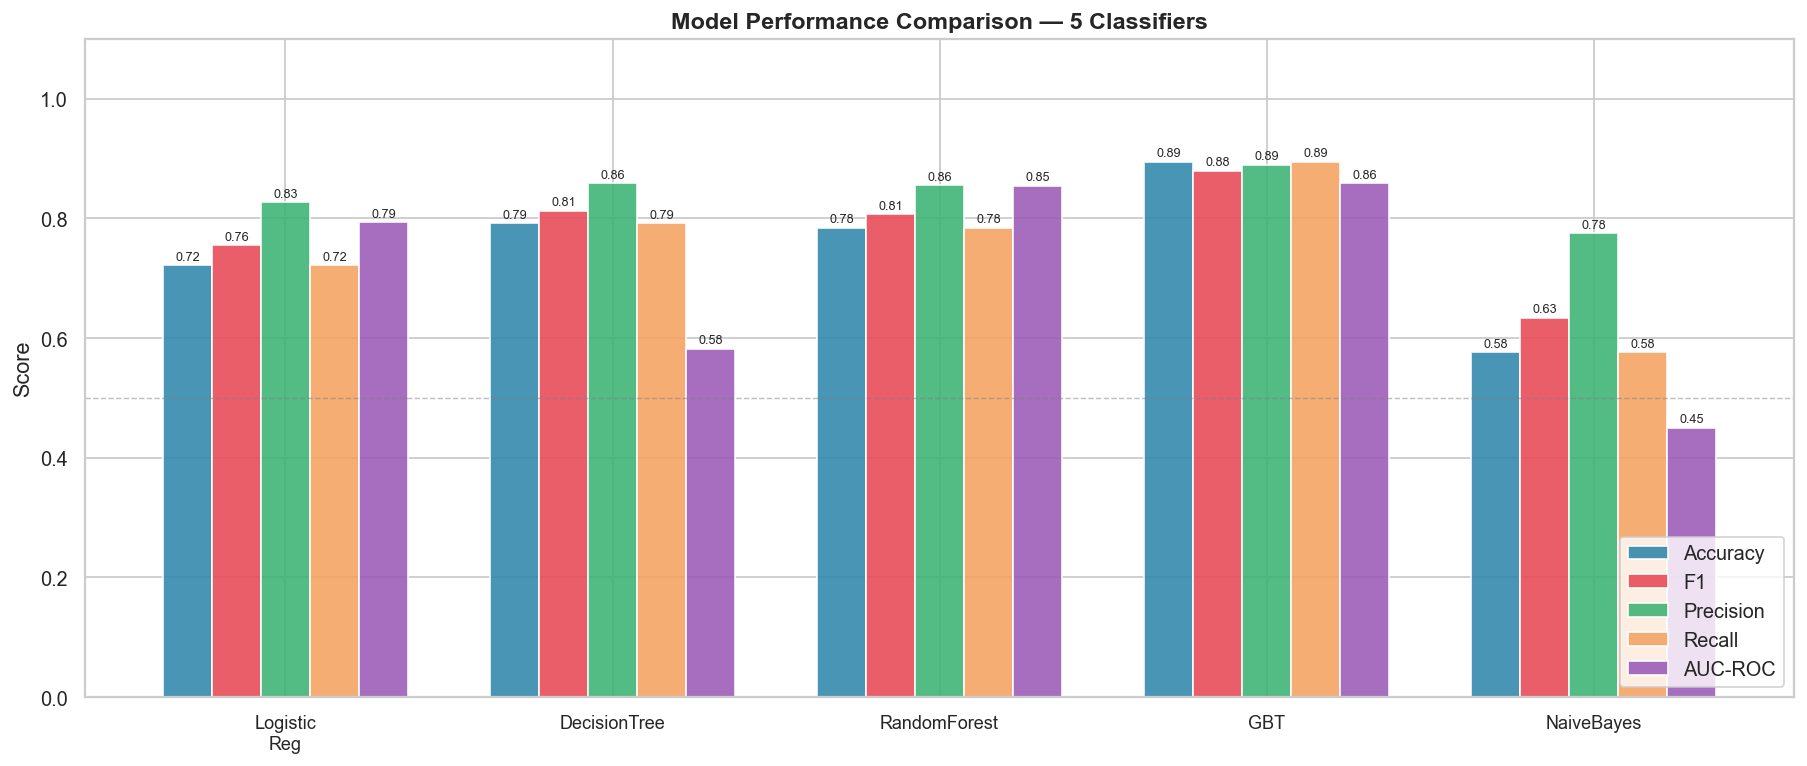

In [17]:
metric_cols   = ['accuracy','f1','precision','recall','auc_roc']
metric_labels = ['Accuracy','F1','Precision','Recall','AUC-ROC']
short_names   = [m.replace('Classifier','').replace('Regression','\nReg')
                 for m in metrics_df['model']]
x      = np.arange(len(metrics_df))
width  = 0.15
colors = ['#2E86AB','#E84855','#3BB273','#F4A261','#9B59B6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (c, lbl) in enumerate(zip(metric_cols, metric_labels)):
    vals = metrics_df[c].values
    bars = ax.bar(x + i*width, vals, width, label=lbl, color=colors[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width*2)
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — 5 Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
save('fig1_model_comparison.png')
plt.show()

## Figure 2 — Feature Importance

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig2_feature_importance.png


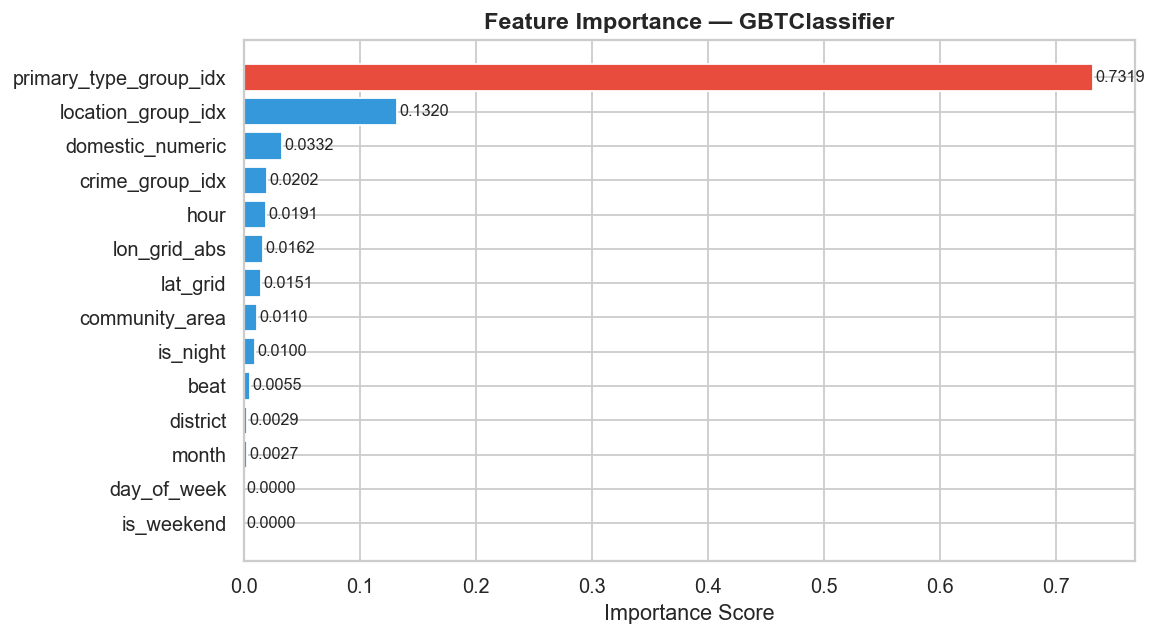

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(imp_df))]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors_imp[::-1])
for i, (feat, val) in enumerate(zip(imp_df['feature'][::-1], imp_df['importance'][::-1])):
    ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title(f'Feature Importance — {best_model}', fontsize=13, fontweight='bold')
plt.tight_layout()
save('fig2_feature_importance.png')
plt.show()

## Figure 3 — Confusion Matrix

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig3_confusion_matrix.png


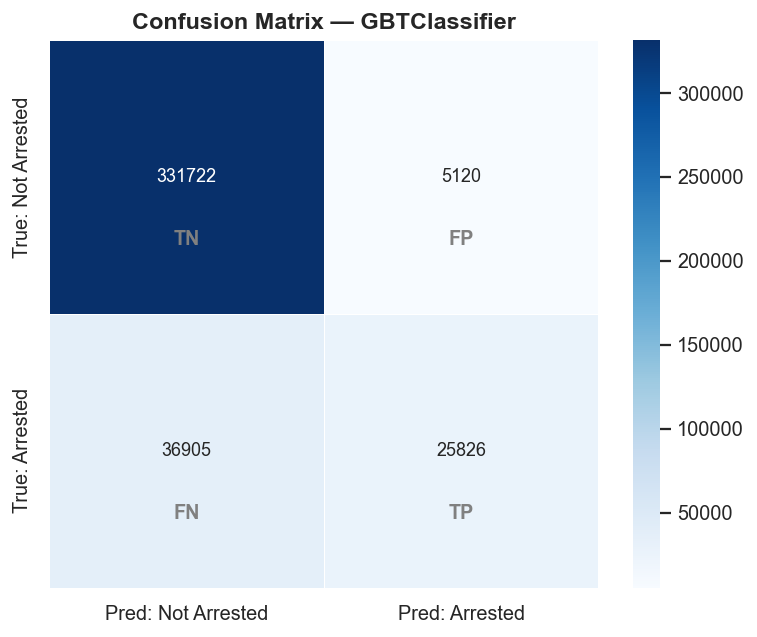

Accuracy  : 0.8948
Precision : 0.8346
Recall    : 0.4117


In [19]:
cm = np.zeros((2,2), dtype=int)
for _, r in cm_df.iterrows():
    cm[int(r['label'])][int(r['prediction'])] = int(r['count'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Not Arrested','Pred: Arrested'],
            yticklabels=['True: Not Arrested','True: Arrested'],
            linewidths=0.5)
for (r,c), lbl in [((0,0),'TN'),((0,1),'FP'),((1,0),'FN'),((1,1),'TP')]:
    ax.text(c+0.5, r+0.75, lbl, ha='center', color='gray', fontsize=11, fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_model}', fontsize=13, fontweight='bold')
plt.tight_layout()
save('fig3_confusion_matrix.png')
plt.show()

tn,fp,fn,tp = cm[0,0],cm[0,1],cm[1,0],cm[1,1]
total_test  = tn+fp+fn+tp
print(f'Accuracy  : {(tn+tp)/total_test:.4f}')
print(f'Precision : {tp/(tp+fp):.4f}')
print(f'Recall    : {tp/(tp+fn):.4f}')

## Figure 4 — Zaman Serisi: Saatlik & Günlük Trend

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig4_time_trends.png


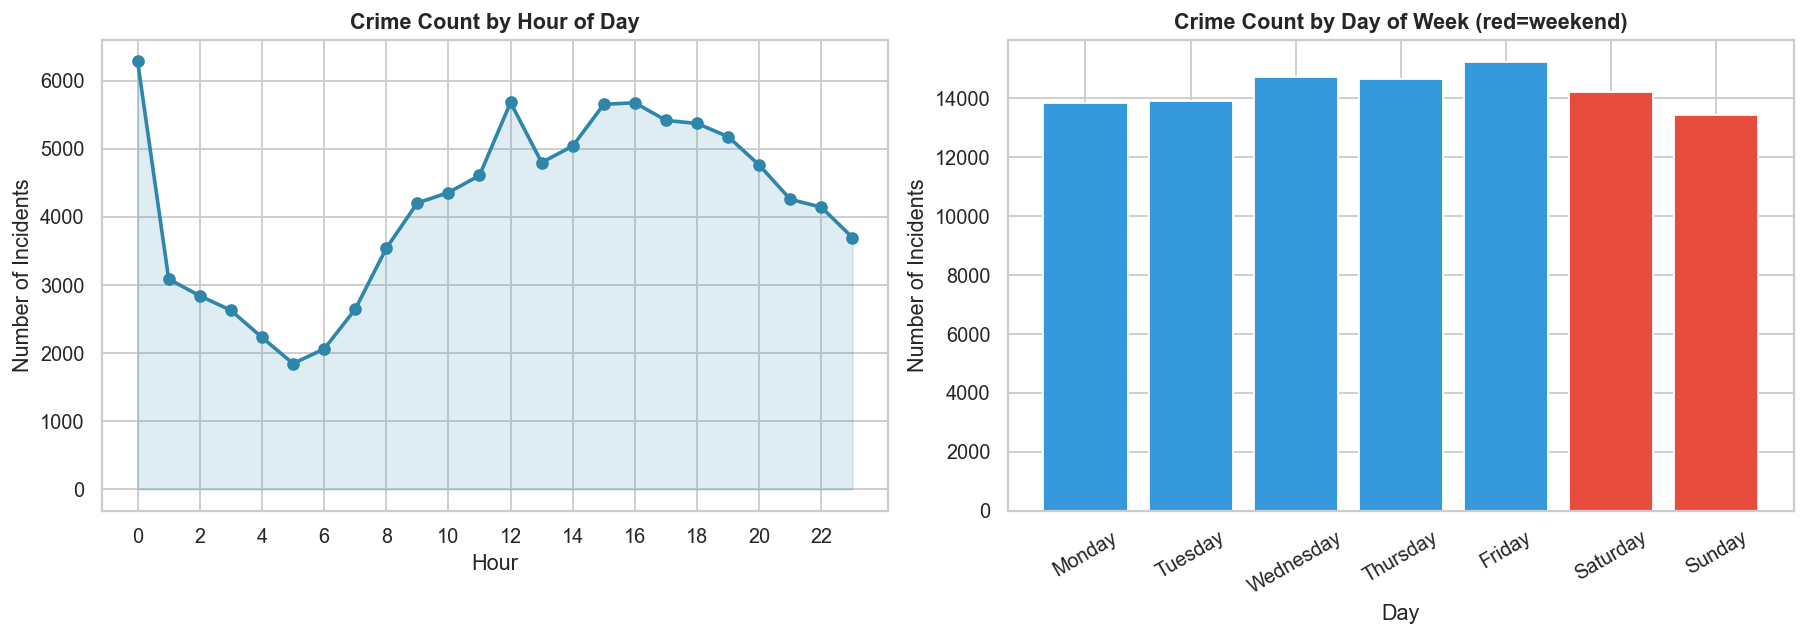

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
hourly = df.groupby('hour').size().reset_index(name='count')
axes[0].plot(hourly['hour'], hourly['count'], marker='o', color='#2E86AB', linewidth=2)
axes[0].fill_between(hourly['hour'], hourly['count'], alpha=0.15, color='#2E86AB')
axes[0].set_title('Crime Count by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_xticks(range(0,24,2))

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week').size().reindex(day_order).reset_index(name='count')
bar_colors = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in day_order]
axes[1].bar(daily['day_of_week'], daily['count'], color=bar_colors)
axes[1].set_title('Crime Count by Day of Week (red=weekend)', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Incidents')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
save('fig4_time_trends.png')
plt.show()

## Figure 5 — Veri Dağılımı: Crime Types & Arrest Rate

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig5_crime_distribution.png


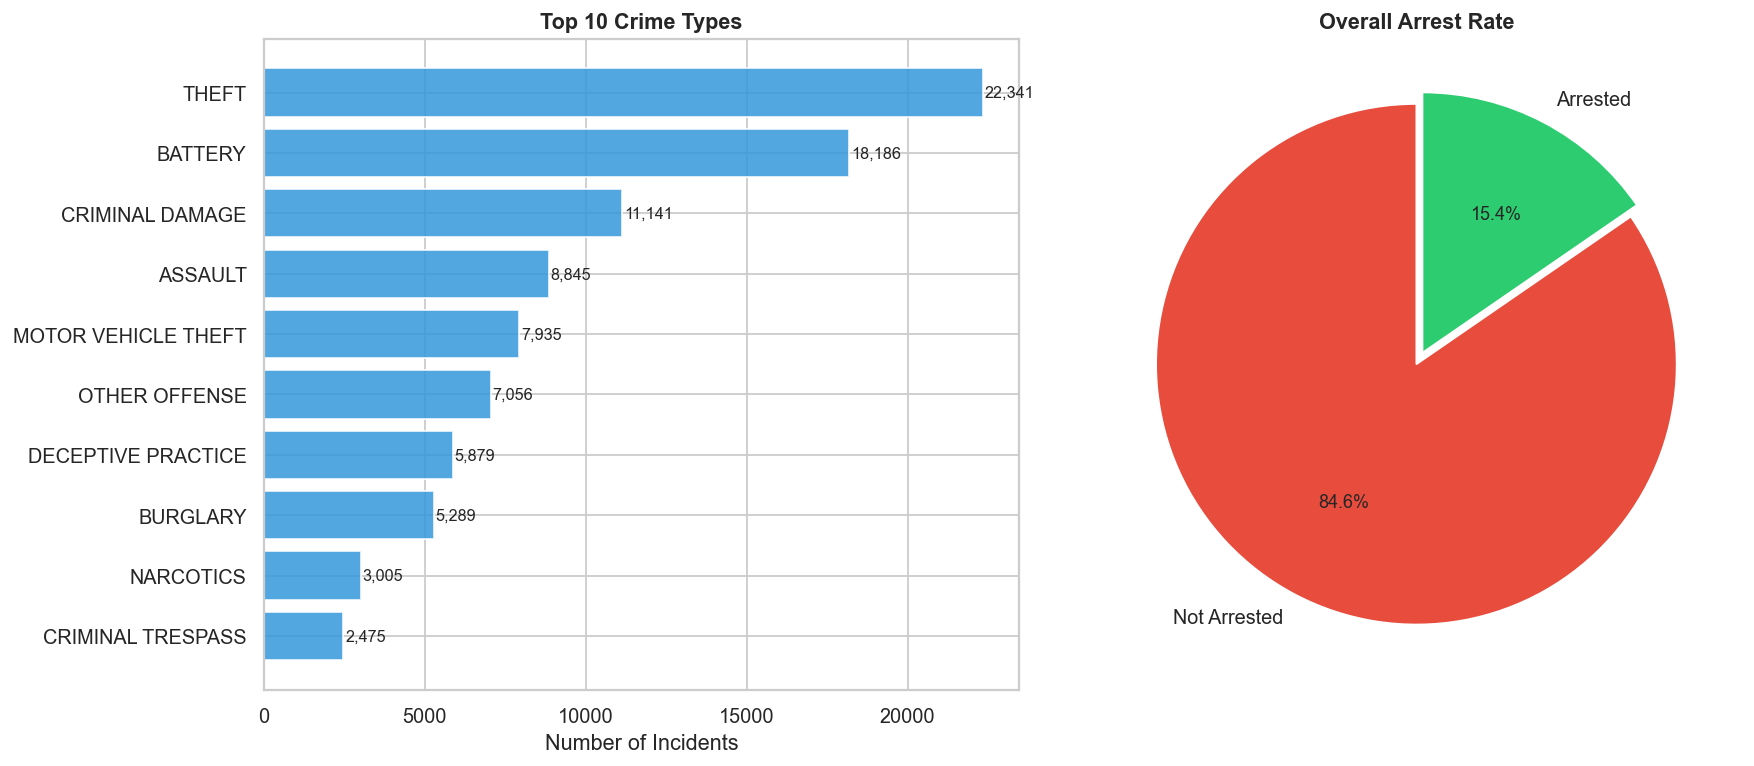

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 crime types
top10 = df['primary_type'].value_counts().head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#3498db', alpha=0.85)
axes[0].set_title('Top 10 Crime Types', fontweight='bold')
axes[0].set_xlabel('Number of Incidents')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v+50, i, f'{v:,}', va='center', fontsize=9)

# Arrest rate pie
arr_counts = df['arrested'].value_counts()
axes[1].pie(
    arr_counts.values,
    labels=['Not Arrested','Arrested'],
    autopct='%1.1f%%',
    colors=['#e74c3c','#2ecc71'],
    startangle=90, explode=[0, 0.05]
)
axes[1].set_title('Overall Arrest Rate', fontweight='bold')

plt.tight_layout()
save('fig5_crime_distribution.png')
plt.show()

## Figure 6 — Arrest Rate by Crime Type (Top 10)

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig6_arrest_rate_by_type.png


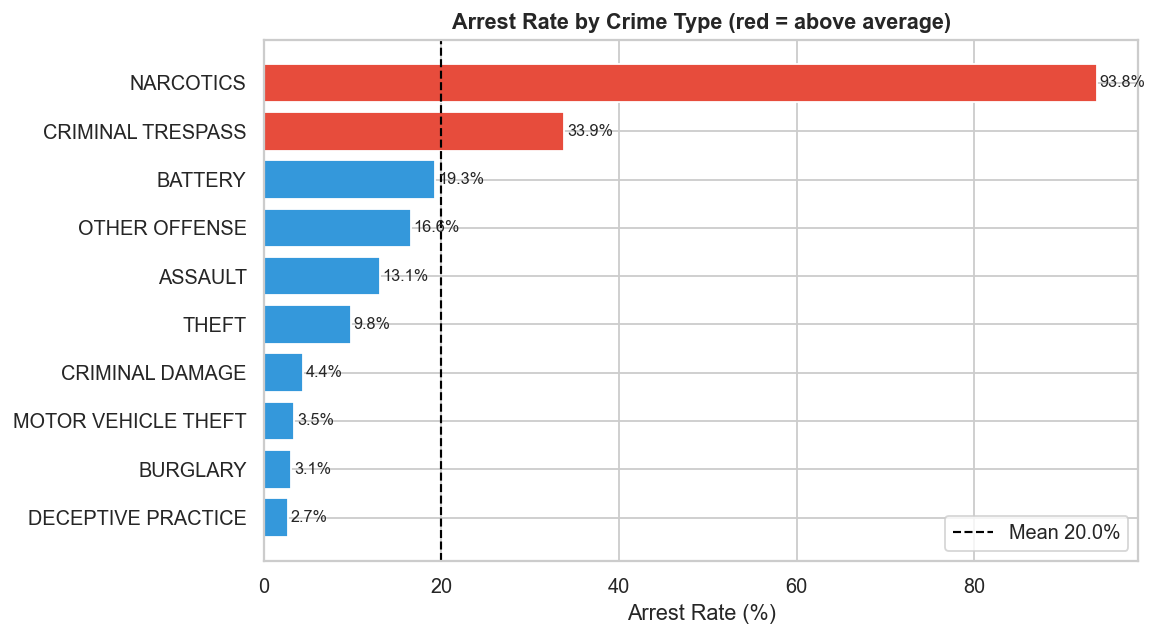

In [22]:
top10_types  = df['primary_type'].value_counts().head(10).index
arrest_rates = (
    df[df['primary_type'].isin(top10_types)]
    .groupby('primary_type')['arrested']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors4 = ['#e74c3c' if v > arrest_rates.mean() else '#3498db' for v in arrest_rates]
bars = ax.barh(arrest_rates.index, arrest_rates.values * 100, color=colors4)
ax.axvline(arrest_rates.mean()*100, color='black', linestyle='--', linewidth=1.2,
           label=f'Mean {arrest_rates.mean()*100:.1f}%')
for bar, v in zip(bars, arrest_rates.values):
    ax.text(v*100+0.3, bar.get_y()+bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (red = above average)', fontweight='bold')
ax.legend()
plt.tight_layout()
save('fig6_arrest_rate_by_type.png')
plt.show()

## Figure 7 — District Heatmap & Monthly Trend

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig7_monthly_district.png


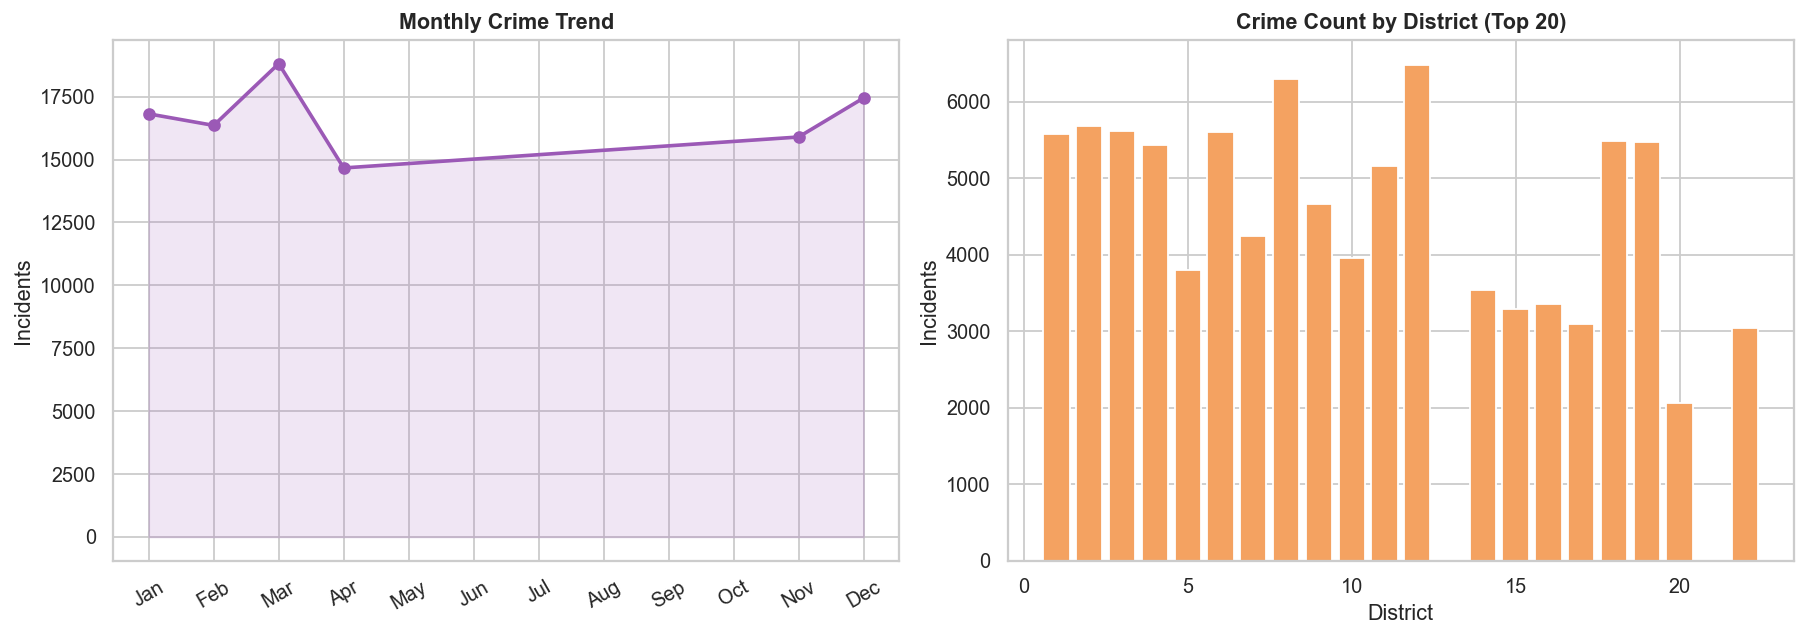

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly trend
monthly = df.groupby('month').size().reset_index(name='count')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].plot(monthly['month'], monthly['count'], marker='o', color='#9B59B6', linewidth=2)
axes[0].fill_between(monthly['month'], monthly['count'], alpha=0.15, color='#9B59B6')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, rotation=30)
axes[0].set_title('Monthly Crime Trend', fontweight='bold')
axes[0].set_ylabel('Incidents')

# District crime count
dist = df['district'].value_counts().dropna().sort_index().head(20)
axes[1].bar(dist.index.astype(int), dist.values, color='#F4A261')
axes[1].set_title('Crime Count by District (Top 20)', fontweight='bold')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Incidents')

plt.tight_layout()
save('fig7_monthly_district.png')
plt.show()

## Figure 8 — Day × Hour Heatmap

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig8_weekday_hour_heatmap.png


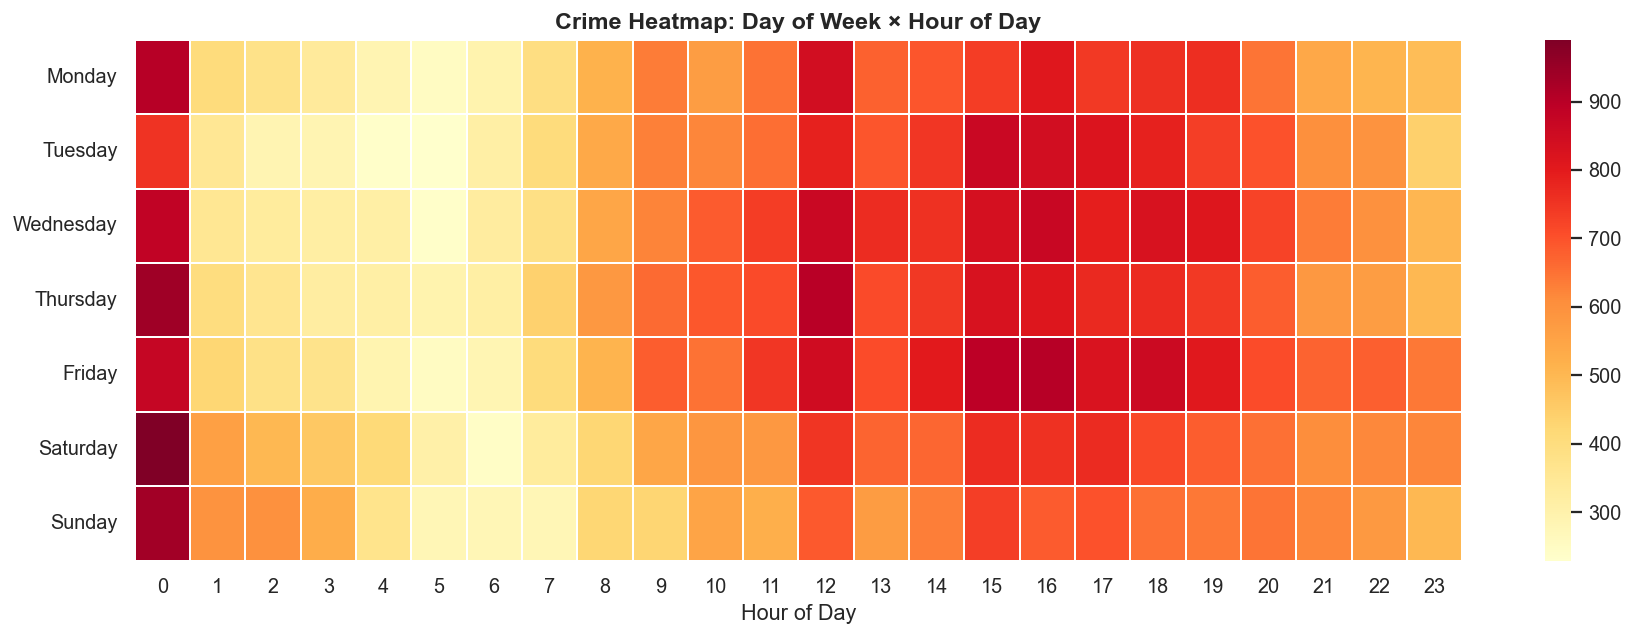

In [24]:
day_order2 = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order2)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.2)
ax.set_title('Crime Heatmap: Day of Week × Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
save('fig8_weekday_hour_heatmap.png')
plt.show()

## Figure 9 — Domestic & Location Distribution

  → /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard/fig9_domestic_location.png


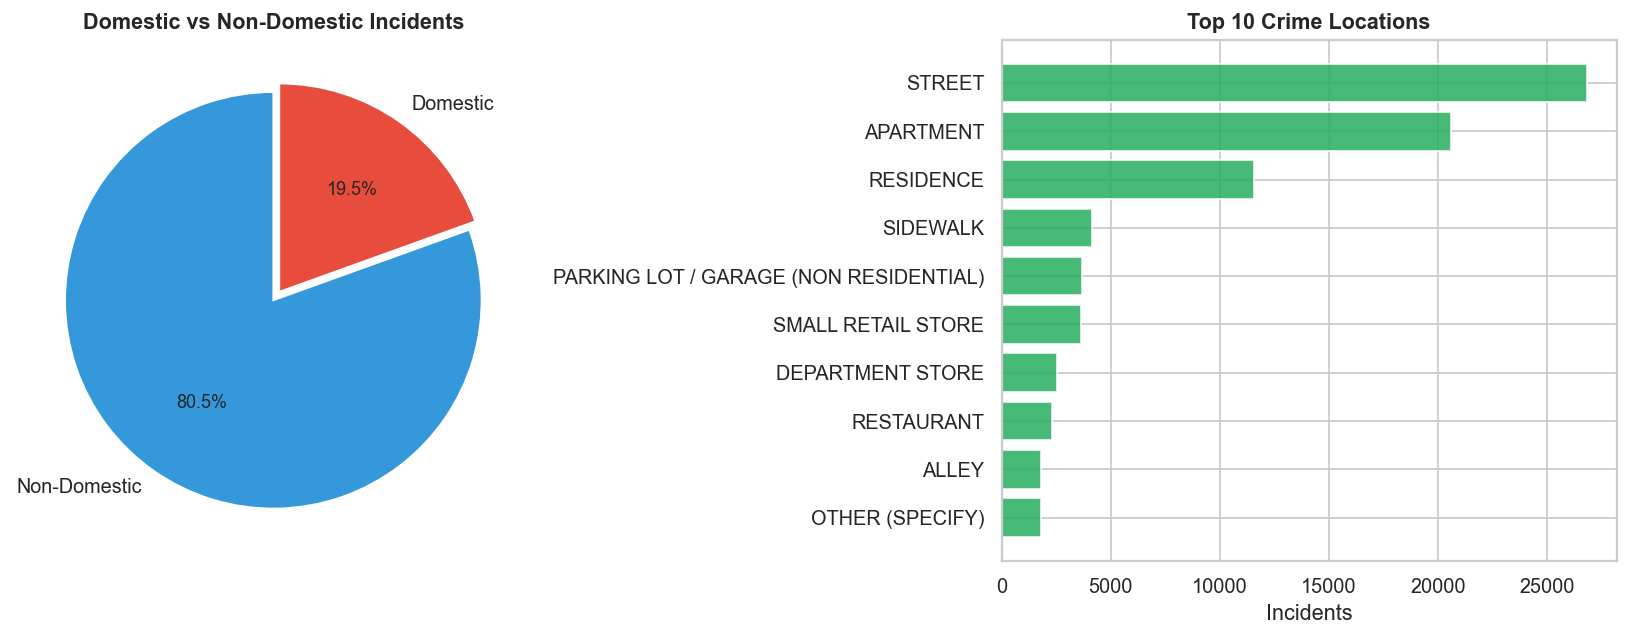

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Domestic pie
dom = df['domestic'].astype(str).str.lower().isin(['true','1']).value_counts()
axes[0].pie(dom.values, labels=['Non-Domestic','Domestic'],
            autopct='%1.1f%%', colors=['#3498db','#e74c3c'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Domestic vs Non-Domestic Incidents', fontweight='bold')

# Top 10 locations
loc = df['location_description'].value_counts().head(10)
axes[1].barh(loc.index[::-1], loc.values[::-1], color='#27ae60', alpha=0.85)
axes[1].set_title('Top 10 Crime Locations', fontweight='bold')
axes[1].set_xlabel('Incidents')

plt.tight_layout()
save('fig9_domestic_location.png')
plt.show()

## Özet — Tüm Görseller

In [26]:
figures = list(OUT.glob('*.png'))
lines = [
    f'## Dashboard Görselleri — {len(figures)} dosya',
    '',
    '| # | Dosya | Açıklama |',
    '|---|-------|----------|',
    '| 1 | fig1_model_comparison | 5 model × 5 metrik grouped bar |',
    '| 2 | fig2_feature_importance | Horizontal bar — en önemli features |',
    '| 3 | fig3_confusion_matrix | TP/FP/FN/TN heatmap |',
    '| 4 | fig4_time_trends | Saatlik + günlük trend |',
    '| 5 | fig5_crime_distribution | Top 10 crime types + arrest rate pie |',
    '| 6 | fig6_arrest_rate_by_type | Suç tipine göre tutuklama oranı |',
    '| 7 | fig7_monthly_district | Aylık trend + district dağılımı |',
    '| 8 | fig8_weekday_hour_heatmap | Gün × Saat ısı haritası |',
    '| 9 | fig9_domestic_location | Domestic oranı + top 10 lokasyon |',
    '',
    f'**Kayıt dizini:** `{OUT}`',
]
display(Markdown('\n'.join(lines)))
print(f'\n{len(figures)} PNG dosyası {OUT} altında kaydedildi.')

## Dashboard Görselleri — 9 dosya

| # | Dosya | Açıklama |
|---|-------|----------|
| 1 | fig1_model_comparison | 5 model × 5 metrik grouped bar |
| 2 | fig2_feature_importance | Horizontal bar — en önemli features |
| 3 | fig3_confusion_matrix | TP/FP/FN/TN heatmap |
| 4 | fig4_time_trends | Saatlik + günlük trend |
| 5 | fig5_crime_distribution | Top 10 crime types + arrest rate pie |
| 6 | fig6_arrest_rate_by_type | Suç tipine göre tutuklama oranı |
| 7 | fig7_monthly_district | Aylık trend + district dağılımı |
| 8 | fig8_weekday_hour_heatmap | Gün × Saat ısı haritası |
| 9 | fig9_domestic_location | Domestic oranı + top 10 lokasyon |

**Kayıt dizini:** `/Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard`


9 PNG dosyası /Users/emircankartal/Desktop/Dev/chicago-crime-bigdata-pipeline/dashboard/figures/dashboard altında kaydedildi.
